# Rapport de performance — Pipeline acridologique Madagascar

**Issue #10** — Validation walk-forward 2001–2022, analyse du biais de détection et comparaison SIG-LMC.

Ce notebook consolide les résultats des pipelines #07 (présence/absence) et #08 (densité + phase)
pour les campagnes historiques validées en mode walk-forward expanding-window.

> **Note :** Les campagnes 2023–24 sont en mode *inférence uniquement* (aucun label disponible)
> et sont **exclues de toutes les évaluations** présentées ici.

## 0. Configuration

In [1]:
from pathlib import Path
import warnings

import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import numpy as np
import pandas as pd

warnings.filterwarnings("ignore")
plt.rcParams.update({
    "figure.dpi": 120,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.grid": True,
    "grid.alpha": 0.3,
})

# Racine du dépôt (fonctionne que le notebook soit lancé depuis notebooks/ ou la racine)
ROOT = Path("..") if Path("../data").exists() else Path(".")
DATA = ROOT / "data" / "processed"

print(f"Racine détectée : {ROOT.resolve()}")
print(f"Dossier processed : {DATA.resolve()}")

Racine détectée : /Users/olivierrakotondravao/Workspaces/modele_predictif
Dossier processed : /Users/olivierrakotondravao/Workspaces/modele_predictif/data/processed


## 1. Métriques par fold de campagne

In [2]:
# --- Chargement ---
df07 = pd.read_csv(DATA / "07_rapport_walk_forward.csv")
df08 = pd.read_csv(DATA / "08_rapport_walk_forward.csv")

# --- Séparation ligne GLOBAL ---
global07 = df07[df07["campagne_calc"] == "GLOBAL"].copy()
global08 = df08[df08["campagne_calc"] == "GLOBAL"].copy()
folds07  = df07[df07["campagne_calc"] != "GLOBAL"].copy()
folds08  = df08[df08["campagne_calc"] != "GLOBAL"].copy()

# --- Fusion des deux rapports sur campagne_calc ---
df_folds = folds07.merge(
    folds08[["campagne_calc", "n_presence", "rmse_densite", "mae_densite",
              "f1_macro_phase", "recall_G", "threshold_G"]],
    on="campagne_calc",
    how="inner",
)

# Tri chronologique
df_folds = df_folds.sort_values(
    "campagne_calc",
    key=lambda s: s.str.split("-").str[0].astype(int)
).reset_index(drop=True)

print(f"Nombre de folds de validation : {len(df_folds)}")
print(f"Campagnes : {df_folds['campagne_calc'].tolist()}")

Nombre de folds de validation : 8
Campagnes : ['2016-2017', '2017-2018', '2018-2019', '2019-2020', '2020-2021', '2021-2022', '2024-2025', '2025-2026']


In [3]:
# --- Affichage du tableau des métriques par fold ---
COLS_DISPLAY = [
    "campagne_calc", "n_positifs", "n_negatifs",
    "auc_roc", "f1", "precision", "recall",
    "rmse_densite", "f1_macro_phase", "recall_G",
]
cols_present = [c for c in COLS_DISPLAY if c in df_folds.columns]

numeric_cols = [c for c in cols_present if c not in ("campagne_calc",)]

(
    df_folds[cols_present]
    .style
    .format({c: "{:.4f}" for c in numeric_cols
             if df_folds[c].dtype.kind == "f"}, na_rep="—")
    .highlight_max(subset=[c for c in ["auc_roc", "f1", "f1_macro_phase", "recall_G"]
                            if c in df_folds.columns],
                   color="#d4edda")
    .highlight_min(subset=[c for c in ["auc_roc", "f1", "f1_macro_phase", "recall_G"]
                            if c in df_folds.columns],
                   color="#f8d7da")
    .set_caption("Tableau 1 — Métriques walk-forward par campagne de validation")
)

,campagne_calc,n_positifs,n_negatifs,auc_roc,f1,precision,recall,rmse_densite,f1_macro_phase,recall_G
0,2016-2017,542,169,0.9771,0.9538,0.9960,0.9151,940.3081,0.3025,0.6562
1,2017-2018,768,187,0.9644,0.9507,0.9874,0.9167,323.0723,0.2046,0.0000
2,2018-2019,87,102,0.9399,0.9024,0.9610,0.8506,106.4128,0.3422,0.0000
3,2019-2020,744,95,0.9710,0.9617,0.9778,0.9462,637.5258,0.3127,0.3333
4,2020-2021,430,49,0.9983,0.9942,0.9930,0.9953,1699.5799,0.3096,0.5094
5,2021-2022,316,38,0.9773,0.9790,1.0000,0.9589,1074.3973,0.3023,0.2593
6,2024-2025,1,0,—,1.0000,1.0000,1.0000,—,—,—
7,2025-2026,524,49,0.9715,0.9707,0.9940,0.9485,472.5390,0.2265,0.8000


In [4]:
# --- Ligne GLOBAL (métriques poolées sur toutes les validations) ---
if not global07.empty and not global08.empty:
    global_row = global07.merge(
        global08[["campagne_calc", "rmse_densite", "mae_densite",
                   "f1_macro_phase", "recall_G"]],
        on="campagne_calc", how="left"
    )
    print("\n=== Métriques GLOBALES (toutes validations poolées) ===")
    for col in ["auc_roc", "f1", "precision", "recall",
                "rmse_densite", "f1_macro_phase", "recall_G"]:
        if col in global_row.columns:
            val = global_row[col].iloc[0]
            cible = None
            if col == "auc_roc":   cible = (val >= 0.85, "cible ≥ 0.85")
            if col == "recall_G":  cible = (val >= 0.70, "cible ≥ 0.70")
            statut = ""
            if cible is not None:
                statut = f"  ✓ {cible[1]}" if cible[0] else f"  ✗ {cible[1]}"
            print(f"  {col:25s}: {val:.4f}{statut}")


=== Métriques GLOBALES (toutes validations poolées) ===
  auc_roc                  : 0.9736  ✓ cible ≥ 0.85
  f1                       : 0.9610
  precision                : 0.9959
  recall                   : 0.9285
  rmse_densite             : 870.8143
  f1_macro_phase           : 0.3016
  recall_G                 : 0.3212  ✗ cible ≥ 0.70


## 2. Courbe de performance au fil des campagnes

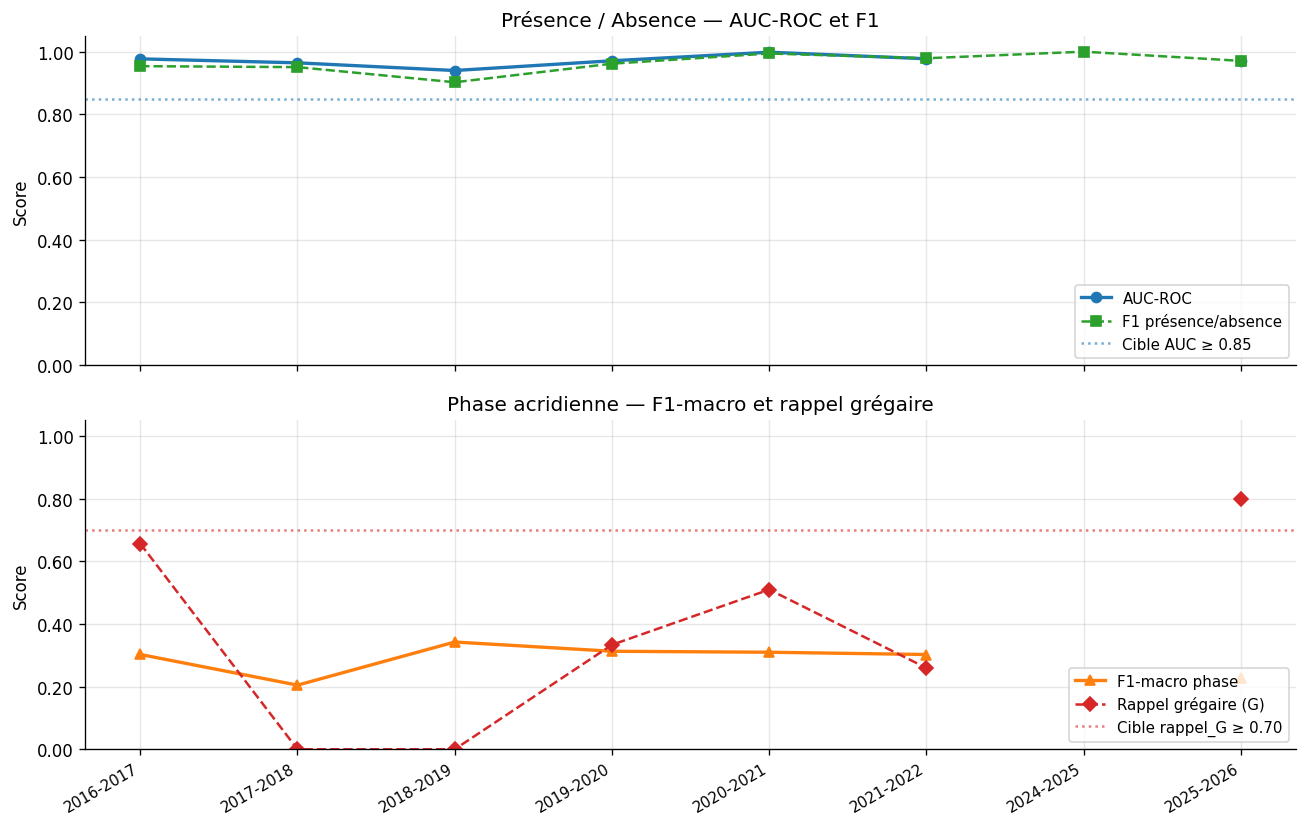

Figure exportée : ../data/processed/10_courbe_performance.png


In [5]:
x = df_folds["campagne_calc"].tolist()
x_idx = range(len(x))

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(11, 7), sharex=True)

# --- Sous-graphique 1 : présence/absence ---
if "auc_roc" in df_folds.columns:
    ax1.plot(x_idx, df_folds["auc_roc"], "o-", label="AUC-ROC", color="#1f77b4", linewidth=2)
if "f1" in df_folds.columns:
    ax1.plot(x_idx, df_folds["f1"], "s--", label="F1 présence/absence", color="#2ca02c", linewidth=1.5)
ax1.axhline(0.85, color="#1f77b4", linestyle=":", alpha=0.6, label="Cible AUC ≥ 0.85")
ax1.set_ylim(0, 1.05)
ax1.set_ylabel("Score")
ax1.set_title("Présence / Absence — AUC-ROC et F1")
ax1.legend(loc="lower right", fontsize=9)
ax1.yaxis.set_major_formatter(mticker.FormatStrFormatter("%.2f"))

# --- Sous-graphique 2 : phase ---
if "f1_macro_phase" in df_folds.columns:
    ax2.plot(x_idx, df_folds["f1_macro_phase"], "^-", label="F1-macro phase", color="#ff7f0e", linewidth=2)
if "recall_G" in df_folds.columns:
    ax2.plot(x_idx, df_folds["recall_G"], "D--", label="Rappel grégaire (G)", color="#d62728", linewidth=1.5)
ax2.axhline(0.70, color="#d62728", linestyle=":", alpha=0.6, label="Cible rappel_G ≥ 0.70")
ax2.set_ylim(0, 1.05)
ax2.set_ylabel("Score")
ax2.set_title("Phase acridienne — F1-macro et rappel grégaire")
ax2.legend(loc="lower right", fontsize=9)
ax2.yaxis.set_major_formatter(mticker.FormatStrFormatter("%.2f"))
ax2.set_xticks(list(x_idx))
ax2.set_xticklabels(x, rotation=30, ha="right", fontsize=9)

fig.tight_layout()
out_png = DATA / "10_courbe_performance.png"
fig.savefig(out_png, bbox_inches="tight")
plt.show()
print(f"Figure exportée : {out_png}")

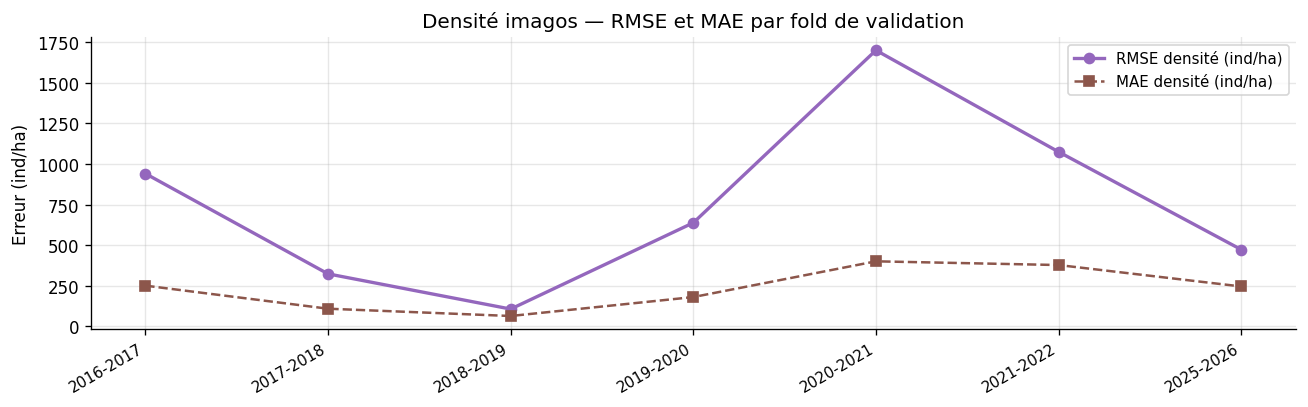

In [6]:
# --- Courbe RMSE densité (optionnelle, sur les folds où elle est disponible) ---
if "rmse_densite" in df_folds.columns and df_folds["rmse_densite"].notna().any():
    df_den = df_folds[["campagne_calc", "rmse_densite", "mae_densite"]].dropna(subset=["rmse_densite"])
    x_den = df_den["campagne_calc"].tolist()
    x_den_idx = range(len(x_den))

    fig3, ax3 = plt.subplots(figsize=(11, 3.5))
    ax3.plot(x_den_idx, df_den["rmse_densite"], "o-", label="RMSE densité (ind/ha)",
             color="#9467bd", linewidth=2)
    if "mae_densite" in df_den.columns:
        ax3.plot(x_den_idx, df_den["mae_densite"], "s--", label="MAE densité (ind/ha)",
                 color="#8c564b", linewidth=1.5)
    ax3.set_xticks(list(x_den_idx))
    ax3.set_xticklabels(x_den, rotation=30, ha="right", fontsize=9)
    ax3.set_ylabel("Erreur (ind/ha)")
    ax3.set_title("Densité imagos — RMSE et MAE par fold de validation")
    ax3.legend(fontsize=9)
    fig3.tight_layout()
    plt.show()
else:
    print("RMSE densité non disponible pour les folds de validation.")

## 3. Analyse du biais de détection

L'effort de prospection (`effort_prospection`) représente le nombre de relevés effectués
dans une région naturelle × décade. Les régions peu prospectées peuvent paraître « absentes »
alors que des populations acridennes y sont présentes — c'est un biais de sous-détection
systématique dans les labels d'entraînement eux-mêmes, indépendamment du modèle.

In [7]:
# --- Chargement de la table d'entraînement ---
df06 = pd.read_parquet(DATA / "06_table_entrainement_unifiee.parquet")

# Uniquement le split validation (campagnes labellisées hors train, 2023-24 exclu)
val = df06[df06["split"] == "validation"].copy()
val["label"] = val["label"].astype(float)

print(f"Lignes validation : {len(val)}")
print(f"Campagnes de validation : {sorted(val['campagne_calc'].unique())}")
print(f"Effort moyen : {val['effort_prospection'].mean():.2f}  |  médiane : {val['effort_prospection'].median():.0f}")
print(f"Taux de présence global : {val['label'].mean():.3f}")

Lignes validation : 4101
Campagnes de validation : ['2016-2017', '2017-2018', '2018-2019', '2019-2020', '2020-2021', '2021-2022', '2024-2025', '2025-2026']
Effort moyen : 3.75  |  médiane : 2
Taux de présence global : 0.832


### 3a. Effort de prospection vs taux de présence par région naturelle

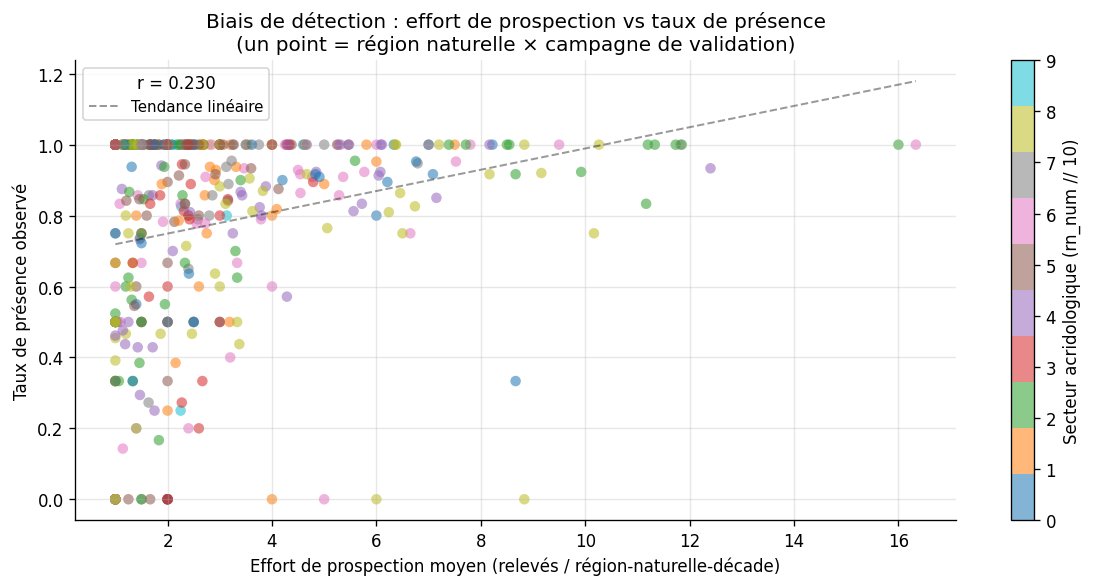

In [8]:
# Agrégation par (rn_nom × campagne_calc)
agg_region = (
    val.groupby(["rn_nom", "campagne_calc"], observed=True)
    .agg(
        effort_mean=("effort_prospection", "mean"),
        taux_presence=("label", "mean"),
        n_decades=("campagne_decade", "count"),
    )
    .reset_index()
)

# Colorier par numéro de région (proxy secteur acridologique)
if "rn_num" in val.columns:
    rn_num_map = val.groupby("rn_nom", observed=True)["rn_num"].first().to_dict()
    agg_region["rn_num"] = agg_region["rn_nom"].map(rn_num_map)
    agg_region["secteur"] = (agg_region["rn_num"] // 10).fillna(0).astype(int)
else:
    agg_region["secteur"] = 0

fig, ax = plt.subplots(figsize=(10, 5))
scatter = ax.scatter(
    agg_region["effort_mean"],
    agg_region["taux_presence"],
    c=agg_region["secteur"],
    cmap="tab10",
    alpha=0.55,
    s=40,
    edgecolors="none",
)
plt.colorbar(scatter, ax=ax, label="Secteur acridologique (rn_num // 10)")

# Droite de tendance
mask_valid = agg_region[["effort_mean", "taux_presence"]].notna().all(axis=1)
if mask_valid.sum() > 5:
    x_fit = agg_region.loc[mask_valid, "effort_mean"].values
    y_fit = agg_region.loc[mask_valid, "taux_presence"].values
    coef = np.polyfit(x_fit, y_fit, 1)
    x_line = np.linspace(x_fit.min(), x_fit.max(), 100)
    ax.plot(x_line, np.polyval(coef, x_line), "k--", alpha=0.4, linewidth=1.2, label="Tendance linéaire")
    corr = np.corrcoef(x_fit, y_fit)[0, 1]
    ax.legend(title=f"r = {corr:.3f}", fontsize=9)

ax.set_xlabel("Effort de prospection moyen (relevés / région-naturelle-décade)")
ax.set_ylabel("Taux de présence observé")
ax.set_title("Biais de détection : effort de prospection vs taux de présence\n(un point = région naturelle × campagne de validation)")
fig.tight_layout()
plt.show()

### 3b. Taux de présence par quartile d'effort

In [9]:
# Quartile d'effort calculé sur chaque observation individuelle (rn_num × campagne × décade)
val["effort_quartile"] = pd.qcut(
    val["effort_prospection"],
    q=4,
    labels=["Q1\n(faible)", "Q2", "Q3", "Q4\n(fort)"],
    duplicates="drop",
)

quartile_stats = (
    val.groupby("effort_quartile", observed=True)["label"]
    .agg(["mean", "count"])
    .rename(columns={"mean": "taux_presence", "count": "n_obs"})
    .reset_index()
)
print(quartile_stats.to_string(index=False))

fig, ax = plt.subplots(figsize=(7, 4))
bars = ax.bar(
    quartile_stats["effort_quartile"].astype(str),
    quartile_stats["taux_presence"],
    color=["#d62728", "#ff7f0e", "#2ca02c", "#1f77b4"],
    edgecolor="white",
    width=0.6,
)
for bar, n in zip(bars, quartile_stats["n_obs"]):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.005,
        f"n={n}",
        ha="center", va="bottom", fontsize=9, color="#333"
    )
ax.set_xlabel("Quartile d'effort de prospection")
ax.set_ylabel("Taux de présence observé")
ax.set_title("Taux de présence acridienne par quartile d'effort de prospection\n(données de validation, campagnes labellisées uniquement)")
ax.yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1, decimals=1))
fig.tight_layout()
plt.show()

ValueError: Bin labels must be one fewer than the number of bin edges

**Interprétation :** Un taux de présence plus bas dans les quartiles de faible effort (Q1–Q2)
par rapport aux quartiles élevés (Q3–Q4) indique un **biais de sous-détection** :
les zones peu prospectées apparaissent artificiellement « absentes » dans les labels,
ce qui peut amener le modèle à sous-estimer le risque dans ces régions.

Ce biais est inhérent aux données de terrain et indépendant de la qualité du modèle ML.

## 4. Comparaison avec les cartes SIG-LMC historiques

Cette section compare le niveau de risque 0–4 prédit par le modèle avec les cartes
de risque historiques du SIG-LMC du CNA, si les données sont disponibles.

In [10]:
SIG_LMC_DIR = ROOT / "data" / "sig_lmc"

sig_lmc_files = list(SIG_LMC_DIR.glob("*.csv")) + list(SIG_LMC_DIR.glob("*.geojson")) \
    if SIG_LMC_DIR.exists() else []

if sig_lmc_files:
    print(f"Fichiers SIG-LMC trouvés : {[f.name for f in sig_lmc_files]}")

    # Chargement des prédictions de risque du modèle (niveau région naturelle × décade)
    df09 = pd.read_parquet(DATA / "09_rn_risque_decade.parquet")

    # Chargement des données SIG-LMC
    # Format attendu : colonnes AIRE_CODE (ou rn_num), campagne_calc, niveau_risque_siglmc (int 0–4)
    df_siglmc = pd.read_csv(sig_lmc_files[0])
    print(f"Colonnes SIG-LMC : {df_siglmc.columns.tolist()}")
    print(df_siglmc.head(3).to_string())

    # Fusion sur la clé commune (à adapter selon les colonnes disponibles)
    join_key = ["AIRE_CODE", "campagne_calc"] if "AIRE_CODE" in df_siglmc.columns \
        else ["rn_num", "campagne_calc"]

    df_comp = df09.merge(df_siglmc, on=join_key, how="inner")
    print(f"Lignes comparables : {len(df_comp)}")

    if len(df_comp) > 0 and "niveau_risque_siglmc" in df_comp.columns:
        from sklearn.metrics import cohen_kappa_score, confusion_matrix

        # Clés de risque communes
        col_modele = "niveau_risque" if "niveau_risque" in df_comp.columns else "niveau_risque_max"

        y_modele  = df_comp[col_modele].astype(int)
        y_siglmc  = df_comp["niveau_risque_siglmc"].astype(int)

        kappa = cohen_kappa_score(y_siglmc, y_modele)
        accord_exact = (y_modele == y_siglmc).mean()
        accord_pm1   = (abs(y_modele - y_siglmc) <= 1).mean()

        print(f"\n=== Accord modèle vs SIG-LMC ===")
        print(f"  Accord exact          : {accord_exact:.3f} ({accord_exact*100:.1f}%)")
        print(f"  Accord ± 1 niveau     : {accord_pm1:.3f} ({accord_pm1*100:.1f}%)")
        print(f"  Cohen's kappa         : {kappa:.3f}")

        # Matrice de confusion
        levels = list(range(5))
        cm = confusion_matrix(y_siglmc, y_modele, labels=levels)
        fig_cm, ax_cm = plt.subplots(figsize=(6, 5))
        im = ax_cm.imshow(cm, cmap="Blues")
        plt.colorbar(im, ax=ax_cm)
        ax_cm.set_xticks(levels); ax_cm.set_yticks(levels)
        ax_cm.set_xticklabels([f"Modèle\n{l}" for l in levels])
        ax_cm.set_yticklabels([f"SIG-LMC {l}" for l in levels])
        for i in range(5):
            for j in range(5):
                ax_cm.text(j, i, cm[i, j], ha="center", va="center",
                           color="white" if cm[i, j] > cm.max() / 2 else "black", fontsize=9)
        ax_cm.set_title(f"Matrice de confusion — Niveau de risque 0–4\n(κ = {kappa:.3f})")
        fig_cm.tight_layout()
        plt.show()
else:
    print("⚠  Données SIG-LMC non disponibles — section de comparaison ignorée.")
    print()
    print("Pour activer cette section, placer un fichier CSV dans data/sig_lmc/ avec les colonnes :")
    print("  - AIRE_CODE  (str) — code de l'acrido-région (ou rn_num pour la région naturelle)")
    print("  - campagne_calc  (str, ex. '2015-16')")
    print("  - niveau_risque_siglmc  (int 0–4)")
    print()
    print("Puis relancer ce notebook.")

⚠  Données SIG-LMC non disponibles — section de comparaison ignorée.

Pour activer cette section, placer un fichier CSV dans data/sig_lmc/ avec les colonnes :
  - AIRE_CODE  (str) — code de l'acrido-région (ou rn_num pour la région naturelle)
  - campagne_calc  (str, ex. '2015-16')
  - niveau_risque_siglmc  (int 0–4)

Puis relancer ce notebook.


## 5. Synthèse

Récapitulatif des métriques globales (toutes campagnes de validation poolées).

In [13]:
synthese_rows = []

metriques_def = [
    ("auc_roc",        global07,  "AUC-ROC présence/absence",       0.85, "≥"),
    ("f1",             global07,  "F1 présence/absence",             None,  None),
    ("precision",      global07,  "Précision présence/absence",      None,  None),
    ("recall",         global07,  "Rappel présence/absence",         None,  None),
    ("rmse_densite",   global08,  "RMSE densité (ind/ha)",           None,  None),
    ("mae_densite",    global08,  "MAE densité (ind/ha)",            None,  None),
    ("f1_macro_phase", global08,  "F1-macro phase",                  None,  None),
    ("recall_G",       global08,  "Rappel grégaire (G)",             0.70, "≥"),
]

for col, src, label, cible, sens in metriques_def:
    if col not in src.columns or src.empty:
        continue
    val_m = src[col].iloc[0]
    if pd.isna(val_m):
        continue
    statut = ""
    if cible is not None:
        ok = (val_m >= cible) if sens == "≥" else (val_m <= cible)
        statut = f"✓ Cible {sens} {cible}" if ok else f"✗ Cible {sens} {cible}"
    synthese_rows.append({"Métrique": label, "Valeur globale": round(val_m, 4), "Cible": statut})

df_synthese = pd.DataFrame(synthese_rows)

def _color_cible(v):
    if isinstance(v, str) and v.startswith("✓"):
        return "color: green; font-weight: bold"
    if isinstance(v, str) and v.startswith("✗"):
        return "color: red; font-weight: bold"
    return ""

(
    df_synthese.style
    .applymap(_color_cible, subset=["Cible"])
    .format({"Valeur globale": "{:.4f}"})
    .set_caption("Tableau 2 — Synthèse des métriques globales (toutes validations poolées)")
    .hide(axis="index")
)

AttributeError: 'Styler' object has no attribute 'applymap'

In [14]:
# --- Note finale sur les campagnes exclues ---
if "split" in df06.columns:
    n_inference = (df06["split"] == "inference").sum()
    camps_inf = df06.loc[df06["split"] == "inference", "campagne_calc"].unique()
    print("=" * 60)
    print("NOTE : Campagnes exclues de l'évaluation (inférence uniquement)")
    print(f"  {sorted(camps_inf)}")
    print(f"  {n_inference} lignes sans label — aucune métrique calculée sur ces données.")
    print("=" * 60)

NOTE : Campagnes exclues de l'évaluation (inférence uniquement)
  ['2000-2001', '2001-2002', '2002-2003', '2003-2004', '2005-2006', '2007-2008', '2008-2009', '2009-2010', '2010-2011', '2011-2012', '2012-2013', '2013-2014', '2014-2015', '2015-2016', '2016-2017', '2017-2018', '2018-2019', '2019-2020', '2020-2021', '2021-2022', '2024-2025', '2025-2026']
  33070 lignes sans label — aucune métrique calculée sur ces données.
